In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
from google.colab import files

uploaded = files.upload()  # <-- click "Choose Files" and select dirty_cafe_sales.csv from your Desktop

# Grab the filename that was uploaded
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print(f"Loaded '{filename}' with shape {df.shape}")
df.head()

Saving dirty_cafe_sales.csv to dirty_cafe_sales.csv
Loaded 'dirty_cafe_sales.csv' with shape (10000, 8)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [3]:
df.shape
# this fucntion will tell how many rows and coloumn are there in this csv table there are 10k columns and 8 rows

(10000, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [5]:
df.head(10)
#first 10  rows in table


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [6]:

for col in df.columns:
    print(col, '->', df[col].unique()[:12] if df[col].nunique() < 20 else f"{df[col].nunique()} unique values")
    # Checking for the "dirty" placeholder values often hiding as valid-looking strings


Transaction ID -> 10000 unique values
Item -> ['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice' 'Tea']
Quantity -> ['2' '4' '5' '3' '1' 'ERROR' 'UNKNOWN' nan]
Price Per Unit -> ['2.0' '3.0' '1.0' '5.0' '4.0' '1.5' nan 'ERROR' 'UNKNOWN']
Total Spent -> ['4.0' '12.0' 'ERROR' '10.0' '20.0' '9.0' '16.0' '15.0' '25.0' '8.0' '5.0'
 '3.0']
Payment Method -> ['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan]
Location -> ['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR']
Transaction Date -> 367 unique values


In [7]:
# Missing values per column
df.isna().sum()


,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


cleaning of the data as above data states that :
          ### What we found
- `ERROR` and `UNKNOWN` are placeholder strings standing in for missing data (not real categories).
- `Quantity`, `Price Per Unit`, and `Total Spent` are stored as text, not numbers.
- `Transaction Date` is stored as text, not a real date.
- There are genuine `NaN`s too, on top of the `ERROR`/`UNKNOWN` placeholders.

In [8]:
df_clean = df.copy()

#Replace placeholder strings with real NaN across the whole dataframe
df_clean = df_clean.replace(['ERROR', 'UNKNOWN', 'nan', ''], np.nan)

print("Missing values after replacing placeholders:")
df_clean.isna().sum()


Missing values after replacing placeholders:


,0
Transaction ID,0
Item,969
Quantity,479
Price Per Unit,533
Total Spent,502
Payment Method,3178
Location,3961
Transaction Date,460


In [9]:
#Fix data types
numeric_cols = ['Quantity', 'Price Per Unit', 'Total Spent']
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

df_clean['Transaction Date'] = pd.to_datetime(df_clean['Transaction Date'], errors='coerce')

df_clean.dtypes


,0
Transaction ID,object
Item,object
Quantity,float64
Price Per Unit,float64
Total Spent,float64
Payment Method,object
Location,object
Transaction Date,datetime64[ns]


In [10]:
#Recover missing numeric values using the relationship: Total Spent = Quantity * Price Per Unit
#Fill Total Spent when Quantity & Price are known
mask = df_clean['Total Spent'].isna() & df_clean['Quantity'].notna() & df_clean['Price Per Unit'].notna()
df_clean.loc[mask, 'Total Spent'] = df_clean.loc[mask, 'Quantity'] * df_clean.loc[mask, 'Price Per Unit']

# Fill Price Per Unit when Total Spent & Quantity are known
mask = df_clean['Price Per Unit'].isna() & df_clean['Total Spent'].notna() & df_clean['Quantity'].notna() & (df_clean['Quantity'] != 0)
df_clean.loc[mask, 'Price Per Unit'] = df_clean.loc[mask, 'Total Spent'] / df_clean.loc[mask, 'Quantity']

# Fill Quantity when Total Spent & Price Per Unit are known
mask = df_clean['Quantity'].isna() & df_clean['Total Spent'].notna() & df_clean['Price Per Unit'].notna() & (df_clean['Price Per Unit'] != 0)
df_clean.loc[mask, 'Quantity'] = round(df_clean.loc[mask, 'Total Spent'] / df_clean.loc[mask, 'Price Per Unit'])

print("Missing values after reconstructing numeric fields:")
df_clean[numeric_cols].isna().sum()

Missing values after reconstructing numeric fields:


,0
Quantity,38
Price Per Unit,38
Total Spent,40


In [11]:
#Fill in Item name using the known Price Per Unit -> Item mapping (most items have a fixed price)
price_to_item = (
    df_clean.dropna(subset=['Item', 'Price Per Unit'])
    .groupby('Price Per Unit')['Item']
    .agg(lambda x: x.mode()[0])
)

mask = df_clean['Item'].isna() & df_clean['Price Per Unit'].notna()
df_clean.loc[mask, 'Item'] = df_clean.loc[mask, 'Price Per Unit'].map(price_to_item)

print(f"Items still missing: {df_clean['Item'].isna().sum()}")

Items still missing: 6


In [12]:
# Handle remaining categorical missing values
# Payment Method / Location: keep as an explicit "Unknown" category rather than dropping rows
# (dropping would lose real sales data just because payment method wasn't recorded)
df_clean['Payment Method'] = df_clean['Payment Method'].fillna('Unknown')
df_clean['Location'] = df_clean['Location'].fillna('Unknown')

# Rows where Item/Quantity/Price/Total are ALL still missing carry no useful info - drop those
before = len(df_clean)
df_clean = df_clean.dropna(subset=['Item', 'Quantity', 'Price Per Unit', 'Total Spent'], how='all')
print(f"Dropped {before - len(df_clean)} fully-empty transaction rows")


Dropped 0 fully-empty transaction rows


In [13]:
# Final missing value check
df_clean.isna().sum()


,0
Transaction ID,0
Item,6
Quantity,38
Price Per Unit,38
Total Spent,40
Payment Method,0
Location,0
Transaction Date,460


In [14]:
#  Drop any remaining rows still missing critical numeric fields, and duplicates
df_clean = df_clean.dropna(subset=['Quantity', 'Price Per Unit', 'Total Spent'])
df_clean = df_clean.drop_duplicates(subset='Transaction ID')

print(f"Final cleaned shape: {df_clean.shape}  (started at {df.shape})")
df_clean.head()


Final cleaned shape: (9942, 8)  (started at (10000, 8))


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [15]:
df_clean.describe(include='all')

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,9942,9942,9942.000000,9942.000000,9942.000000,9942,9942,9485
unique,9942,8,NaN,NaN,NaN,4,3,NaN
top,TXN_6170729,Juice,NaN,NaN,NaN,Unknown,Unknown,NaN
freq,1,1414,NaN,NaN,NaN,3158,3940,NaN
mean,NaN,NaN,3.025749,2.947848,8.931855,NaN,NaN,2023-07-01 23:58:10.690564096
min,NaN,NaN,1.000000,1.000000,1.000000,NaN,NaN,2023-01-01 00:00:00
25%,NaN,NaN,2.000000,2.000000,4.000000,NaN,NaN,2023-04-01 00:00:00
50%,NaN,NaN,3.000000,3.000000,8.000000,NaN,NaN,2023-07-02 00:00:00
75%,NaN,NaN,4.000000,4.000000,12.000000,NaN,NaN,2023-10-02 00:00:00
max,NaN,NaN,5.000000,5.000000,25.000000,NaN,NaN,2023-12-31 00:00:00


In [16]:
# Revenue by item
item_revenue = df_clean.groupby('Item')['Total Spent'].agg(['sum', 'count', 'mean']).sort_values('sum', ascending=False)
item_revenue.columns = ['Total Revenue', 'Orders', 'Avg Order Value']
item_revenue

,Total Revenue,Orders,Avg Order Value
Item,,,
Salad,19065.0,1268,15.035489
Sandwich,16460.0,1349,12.201631
Smoothie,13296.0,1089,12.209366
Juice,12780.0,1414,9.038190
Cake,10377.0,1134,9.150794
Coffee,7794.0,1284,6.070093
Tea,5443.5,1199,4.540033
Cookie,3585.0,1205,2.975104


In [17]:
# Revenue by payment method
df_clean.groupby('Payment Method')['Total Spent'].sum().sort_values(ascending=False)

,Total Spent
Payment Method,
Unknown,27711.0
Credit Card,20386.5
Digital Wallet,20362.5
Cash,20340.5


In [18]:
# Revenue by location
df_clean.groupby('Location')['Total Spent'].sum().sort_values(ascending=False)

,Total Spent
Location,
Unknown,35280.0
In-store,27073.0
Takeaway,26447.5


In [19]:
# Monthly sales trend
df_clean['Month'] = df_clean['Transaction Date'].dt.to_period('M')
monthly_sales = df_clean.groupby('Month')['Total Spent'].sum()
monthly_sales


,Total Spent
Month,
2023-01,7219.0
2023-02,6626.0
2023-03,7190.5
2023-04,7168.0
2023-05,6916.5
2023-06,7350.0
2023-07,6876.5
2023-08,7049.5
2023-09,6842.0


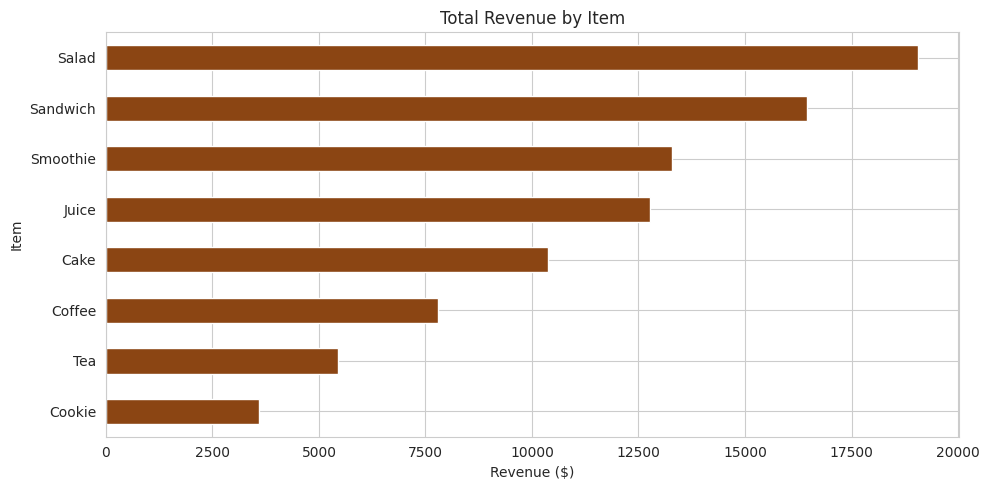

In [20]:
plt.figure(figsize=(10,5))
item_revenue['Total Revenue'].sort_values().plot(kind='barh', color='saddlebrown')
plt.title('Total Revenue by Item')
plt.xlabel('Revenue ($)')
plt.ylabel('Item')
plt.tight_layout()
plt.show()


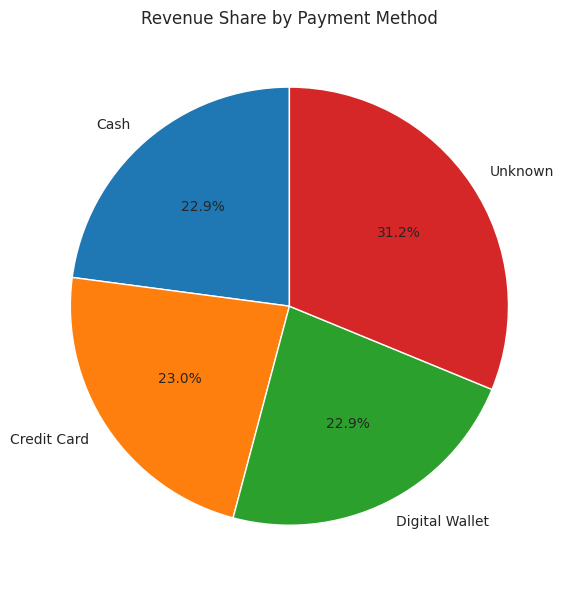

In [21]:
plt.figure(figsize=(6,6))
df_clean.groupby('Payment Method')['Total Spent'].sum().plot(
    kind='pie', autopct='%1.1f%%', startangle=90
)
plt.title('Revenue Share by Payment Method')
plt.ylabel('')
plt.tight_layout()
plt.show()


/tmp/ipykernel_1359/2587628217.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_clean['Location'].value_counts().index,


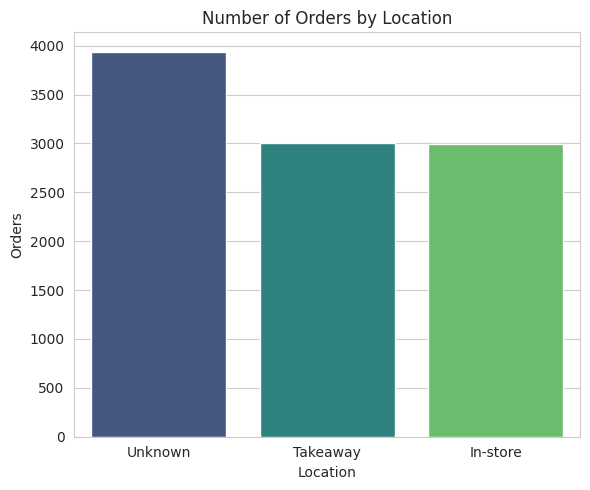

In [22]:
plt.figure(figsize=(6,5))
sns.barplot(x=df_clean['Location'].value_counts().index,
            y=df_clean['Location'].value_counts().values,
            palette='viridis')
plt.title('Number of Orders by Location')
plt.ylabel('Orders')
plt.tight_layout()
plt.show()


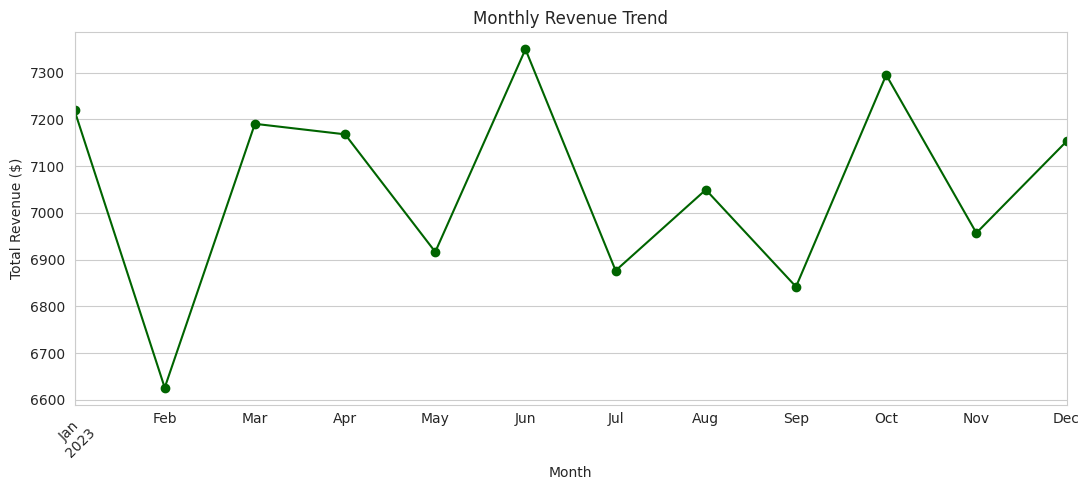

In [23]:
plt.figure(figsize=(11,5))
monthly_sales.plot(kind='line', marker='o', color='darkgreen')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


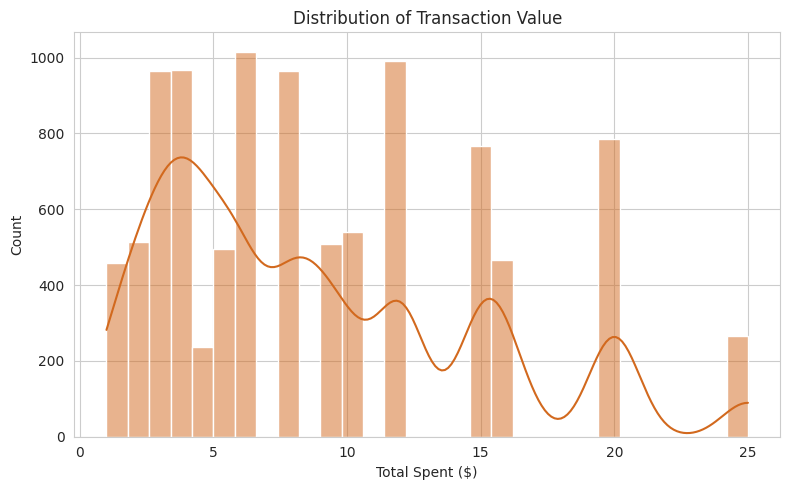

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['Total Spent'], bins=30, kde=True, color='chocolate')
plt.title('Distribution of Transaction Value')
plt.xlabel('Total Spent ($)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1359/2358271500.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow_revenue.index, y=dow_revenue.values, palette='crest')


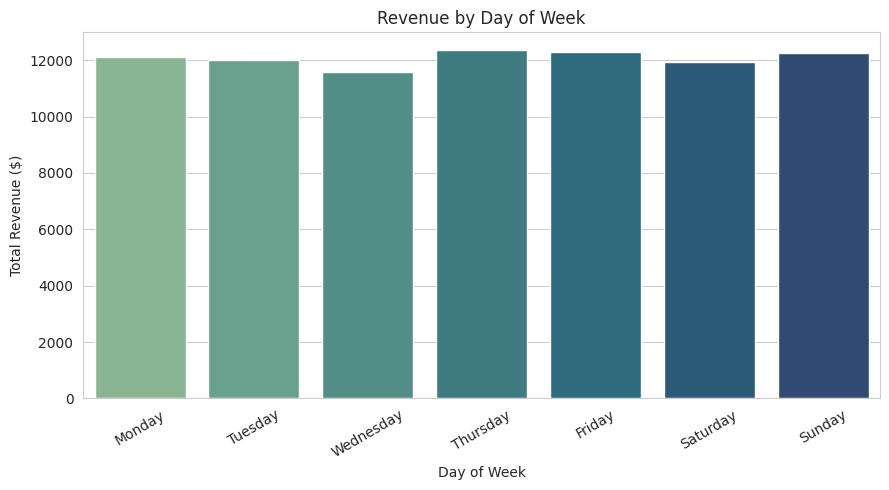

,sum,mean,count
Weekday,64589.5,8.947153,7219
Weekend,24211.0,8.891296,2723


In [25]:
df_clean['Day of Week'] = df_clean['Transaction Date'].dt.day_name()
df_clean['Is Weekend'] = df_clean['Transaction Date'].dt.dayofweek >= 5

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_revenue = df_clean.groupby('Day of Week')['Total Spent'].sum().reindex(dow_order)

plt.figure(figsize=(9,5))
sns.barplot(x=dow_revenue.index, y=dow_revenue.values, palette='crest')
plt.title('Revenue by Day of Week')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

weekend_vs_weekday = df_clean.groupby('Is Weekend')['Total Spent'].agg(['sum','mean','count'])
weekend_vs_weekday.index = ['Weekday', 'Weekend']
weekend_vs_weekday


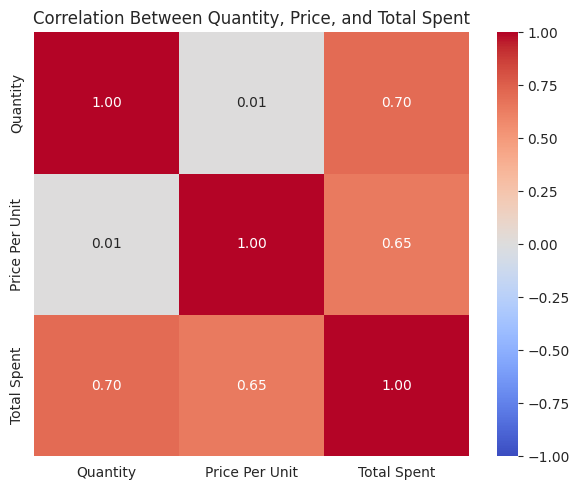

,Quantity,Price Per Unit,Total Spent
Quantity,1.000000,0.006825,0.704091
Price Per Unit,0.006825,1.000000,0.646687
Total Spent,0.704091,0.646687,1.000000


In [26]:
numeric_df = df_clean[['Quantity', 'Price Per Unit', 'Total Spent']]
corr = numeric_df.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Between Quantity, Price, and Total Spent')
plt.tight_layout()
plt.show()

corr

IQR bounds: [-8.00, 24.00]
Number of outlier transactions: 267 (2.7% of data)


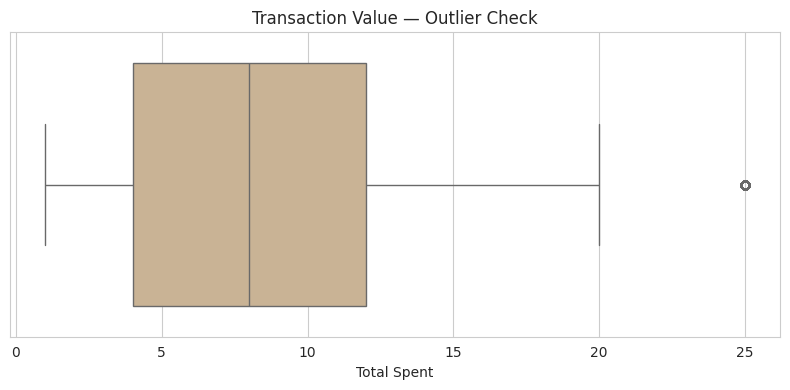

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Month,Day of Week,Is Weekend
9971,TXN_6120851,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-02-04,2023-02,Saturday,True
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07,2023-11,Tuesday,False
51,TXN_6342161,Salad,5.0,5.0,25.0,Unknown,Takeaway,2023-01-08,2023-01,Sunday,True
52,TXN_8914892,Salad,5.0,5.0,25.0,Digital Wallet,Unknown,2023-03-15,2023-03,Wednesday,False
96,TXN_5220895,Salad,5.0,5.0,25.0,Cash,In-store,2023-06-10,2023-06,Saturday,True
100,TXN_9517146,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-10-30,2023-10,Monday,False
150,TXN_8687151,Salad,5.0,5.0,25.0,Cash,Unknown,2023-06-10,2023-06,Saturday,True
157,TXN_4283157,Salad,5.0,5.0,25.0,Digital Wallet,In-store,2023-11-25,2023-11,Saturday,True
177,TXN_1896955,Salad,5.0,5.0,25.0,Unknown,In-store,2023-09-23,2023-09,Saturday,True
214,TXN_8693704,Salad,5.0,5.0,25.0,Cash,In-store,2023-05-04,2023-05,Thursday,False


In [27]:
Q1 = df_clean['Total Spent'].quantile(0.25)
Q3 = df_clean['Total Spent'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['Total Spent'] < lower_bound) | (df_clean['Total Spent'] > upper_bound)]
print(f"IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of outlier transactions: {len(outliers)} ({len(outliers)/len(df_clean)*100:.1f}% of data)")

plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean['Total Spent'], color='tan')
plt.title('Transaction Value — Outlier Check')
plt.tight_layout()
plt.show()

outliers.sort_values('Total Spent', ascending=False).head(10)

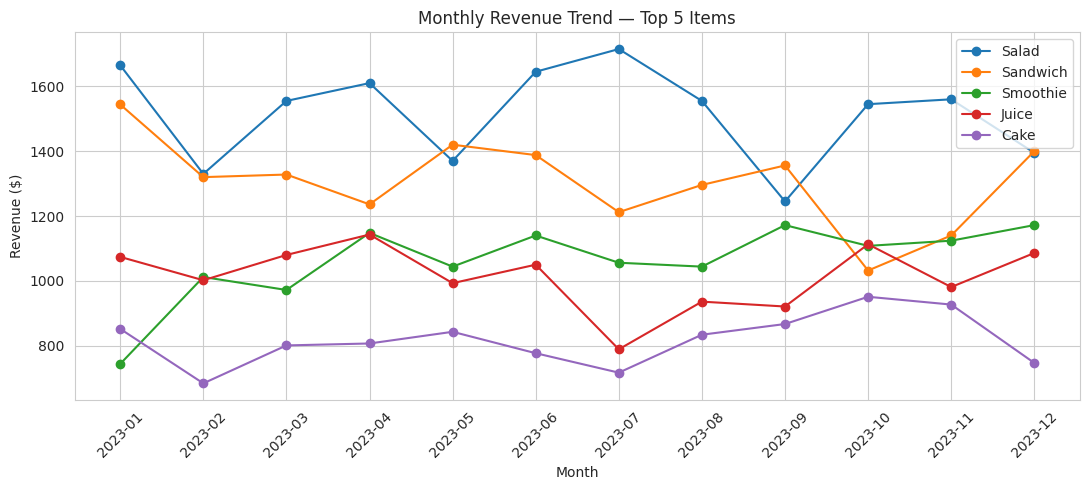

In [28]:
top_items = item_revenue.head(5).index.tolist()

item_monthly = (
    df_clean[df_clean['Item'].isin(top_items)]
    .groupby(['Month', 'Item'])['Total Spent']
    .sum()
    .unstack('Item')
)

plt.figure(figsize=(11,5))
for item in top_items:
    if item in item_monthly.columns:
        plt.plot(item_monthly.index.astype(str), item_monthly[item], marker='o', label=item)

plt.title('Monthly Revenue Trend — Top 5 Items')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

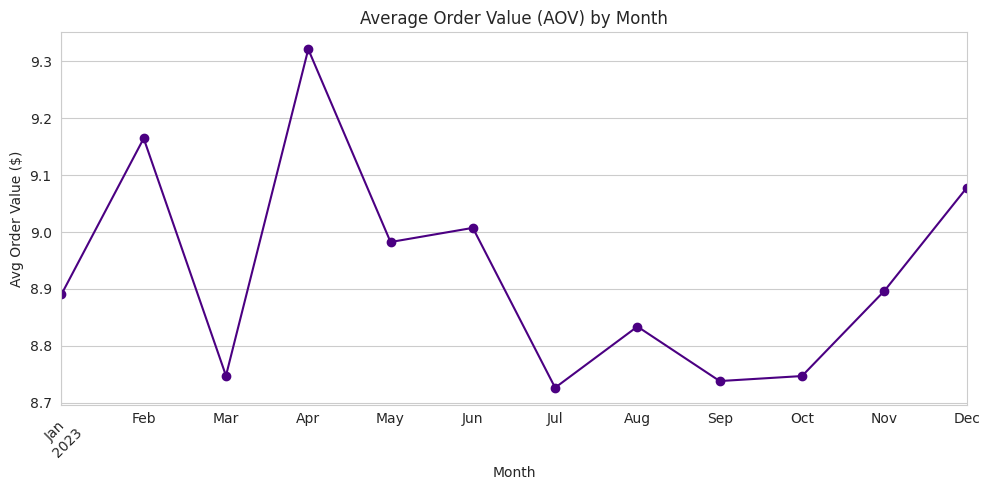

Month-over-month revenue growth (%):


,Total Spent
Month,
2023-01,NaN
2023-02,-8.2
2023-03,8.5
2023-04,-0.3
2023-05,-3.5
2023-06,6.3
2023-07,-6.4
2023-08,2.5
2023-09,-2.9


In [29]:
aov_monthly = df_clean.groupby('Month')['Total Spent'].mean()

plt.figure(figsize=(10,5))
aov_monthly.plot(kind='line', marker='o', color='indigo')
plt.title('Average Order Value (AOV) by Month')
plt.xlabel('Month')
plt.ylabel('Avg Order Value ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Month-over-month growth rate in total revenue
mom_growth = monthly_sales.pct_change() * 100
print("Month-over-month revenue growth (%):")
mom_growth.round(1)

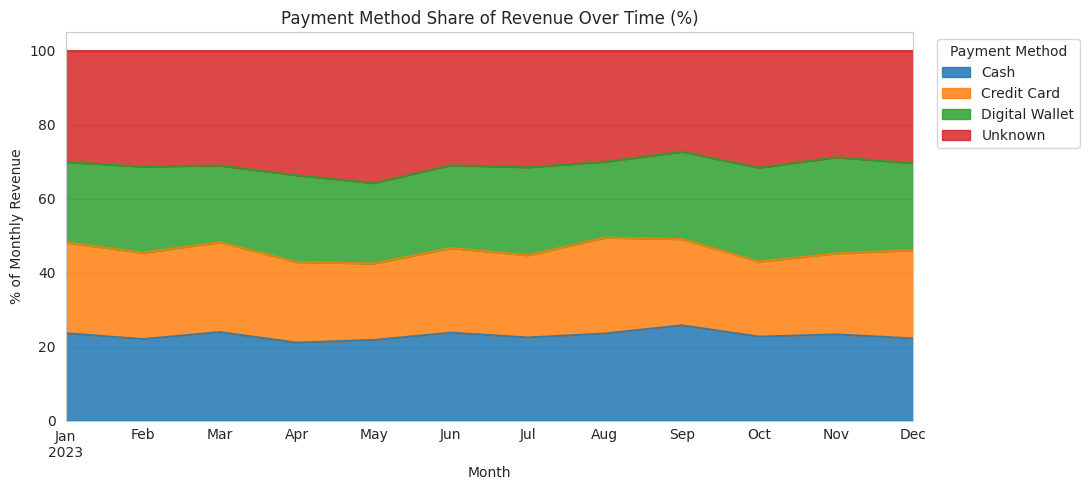

In [30]:
payment_monthly = (
    df_clean.groupby(['Month', 'Payment Method'])['Total Spent']
    .sum()
    .unstack('Payment Method')
)

payment_monthly_share = payment_monthly.div(payment_monthly.sum(axis=1), axis=0) * 100

plt.figure(figsize=(11,5))
payment_monthly_share.plot(kind='area', stacked=True, ax=plt.gca(), alpha=0.85)
plt.title('Payment Method Share of Revenue Over Time (%)')
plt.xlabel('Month')
plt.ylabel('% of Monthly Revenue')
plt.legend(title='Payment Method', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [31]:
df_clean.to_csv('cleaned_cafe_sales.csv', index=False)


from google.colab import files
files.download('cleaned_cafe_sales.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>